In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
train = pd.read_csv("../public_data/train.csv")
test = pd.read_csv("../public_data/test.csv")

train['split'] = "train"
test["split"] = "test"



In [57]:
len(train)

70430

In [58]:
len(test)

14086

In [59]:
df = pd.concat([train,test])

In [60]:
df['Date'] = pd.to_datetime(df['Month'], format='%y-%b').dt.strftime('%m/%y')

In [ ]:
# Normalise categorical columns: lowercase, strip whitespace, replace hyphens with spaces
# Excludes: CustomerID, Month, split, Date (structural), ChurnStatus (target — keep original casing)
cat_cols_to_norm = df.select_dtypes(include='object').columns.tolist()
cat_cols_to_norm = [c for c in cat_cols_to_norm if c not in ['CustomerID', 'Month', 'split', 'Date', 'ChurnStatus']]

for col in cat_cols_to_norm:
    df[col] = df[col].str.strip().str.lower().str.replace('-', ' ', regex=False)

# Propagate back to train/test views so downstream cells remain consistent
train = df[df['split'] == 'train'].drop(columns='split')
test  = df[df['split'] == 'test'].drop(columns='split')

# Verify: check previously drifting columns now have consistent values
for col in ['Contract', 'TransactionMode']:
    print(f"\n{col} unique values after normalisation:")
    print(sorted(df[col].dropna().unique()))

In [61]:
null_values = df.isnull().sum()[df.isnull().sum() > 0]

null_columns = null_values.index

null_columns

Index(['Offer', 'InternetType', 'PrioritySupport', 'DigitalInvoicing'], dtype='object')

In [62]:
null_values_per_month = df.groupby("Date").apply(lambda x: x.isnull().sum())
null_values_per_month[null_columns]

C:\Users\travi\AppData\Local\Temp\ipykernel_24452\3479990375.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  null_values_per_month = df.groupby("Date").apply(lambda x: x.isnull().sum())


,Offer,InternetType,PrioritySupport,DigitalInvoicing
Date,,,,
01/25,4794,1700,0,0
02/25,4868,1702,0,0
03/25,4794,1693,0,0
04/25,4846,1694,0,0
05/25,4826,1716,0,2409
06/25,4858,1698,0,2429
07/25,4850,1735,0,2471
08/25,4816,1672,4105,2398
09/25,4778,1728,4102,2466


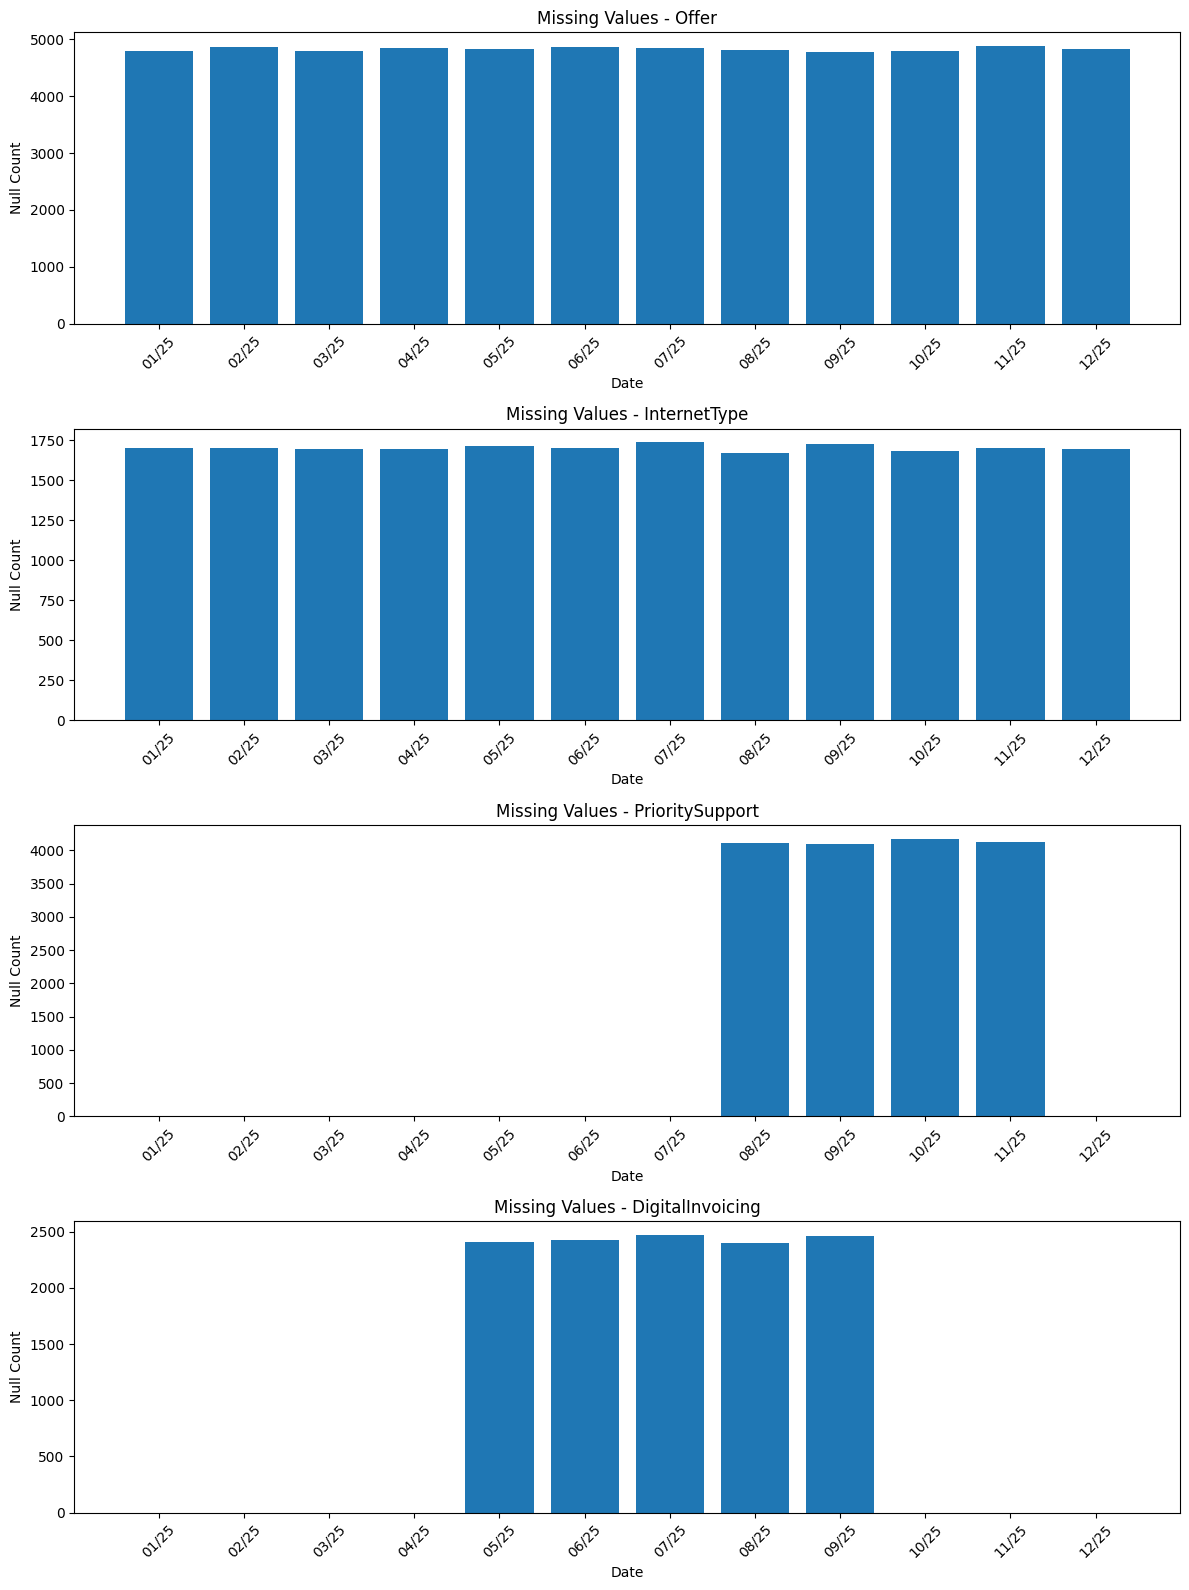

In [63]:
fig, axes = plt.subplots(len(null_columns), 1, figsize=(12, 4 * len(null_columns)))

for i, col in enumerate(null_columns):
    axes[i].bar(null_values_per_month.index, null_values_per_month[col])
    axes[i].set_title(f"Missing Values - {col}")
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Null Count")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols = [x for x in categorical_cols if x not in ['CustomerID', 'Date', "Month", "split", "LocationCity"]]

for col in categorical_cols:
    df[col] = df[col].fillna("null")

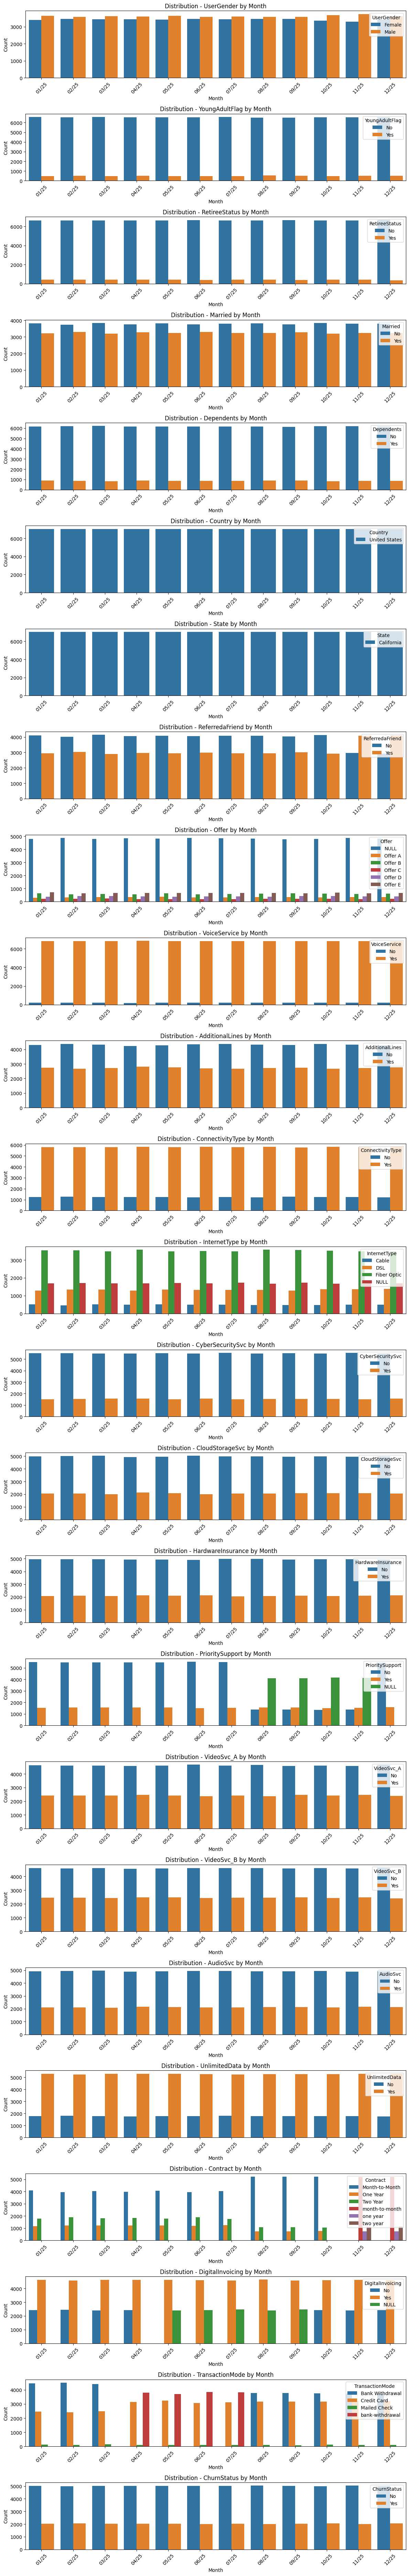

In [65]:


fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(12, 3 * len(categorical_cols)))

for i, col in enumerate(categorical_cols):
    plot_data = df.groupby(["Date", col]).size().reset_index(name="Count")
    sns.barplot(data=plot_data, x="Date", hue=col, y="Count", ax=axes[i])
    axes[i].set_title(f"Distribution - {col} by Month")
    axes[i].set_xlabel("Month")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title=col, loc='upper right')

plt.tight_layout()
plt.show()

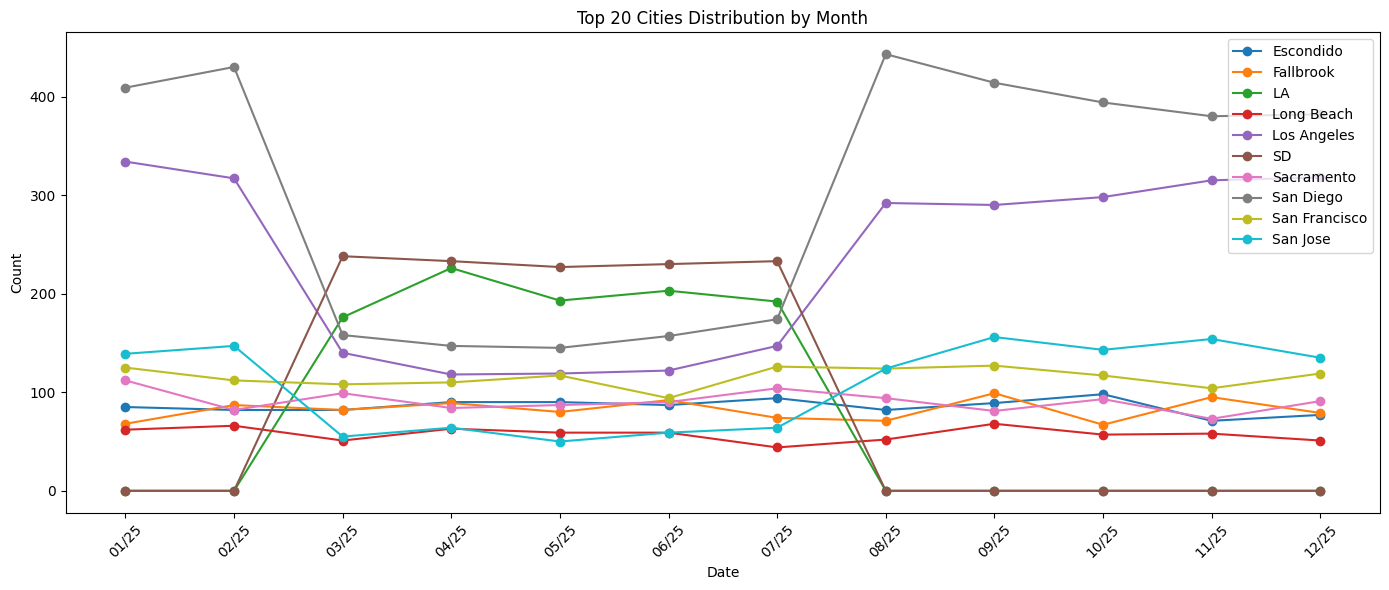

In [68]:
top_cities = df['LocationCity'].value_counts().nlargest(10).index
filtered = df[df['LocationCity'].isin(top_cities)]

plot_data = filtered.groupby(["Date", "LocationCity"]).size().unstack(fill_value=0)

plt.figure(figsize=(14, 6))
for city in plot_data.columns:
    plt.plot(plot_data.index, plot_data[city], marker='o', label=city)

plt.xlabel("Date")
plt.ylabel("Count")
plt.title("Top 20 Cities Distribution by Month")
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

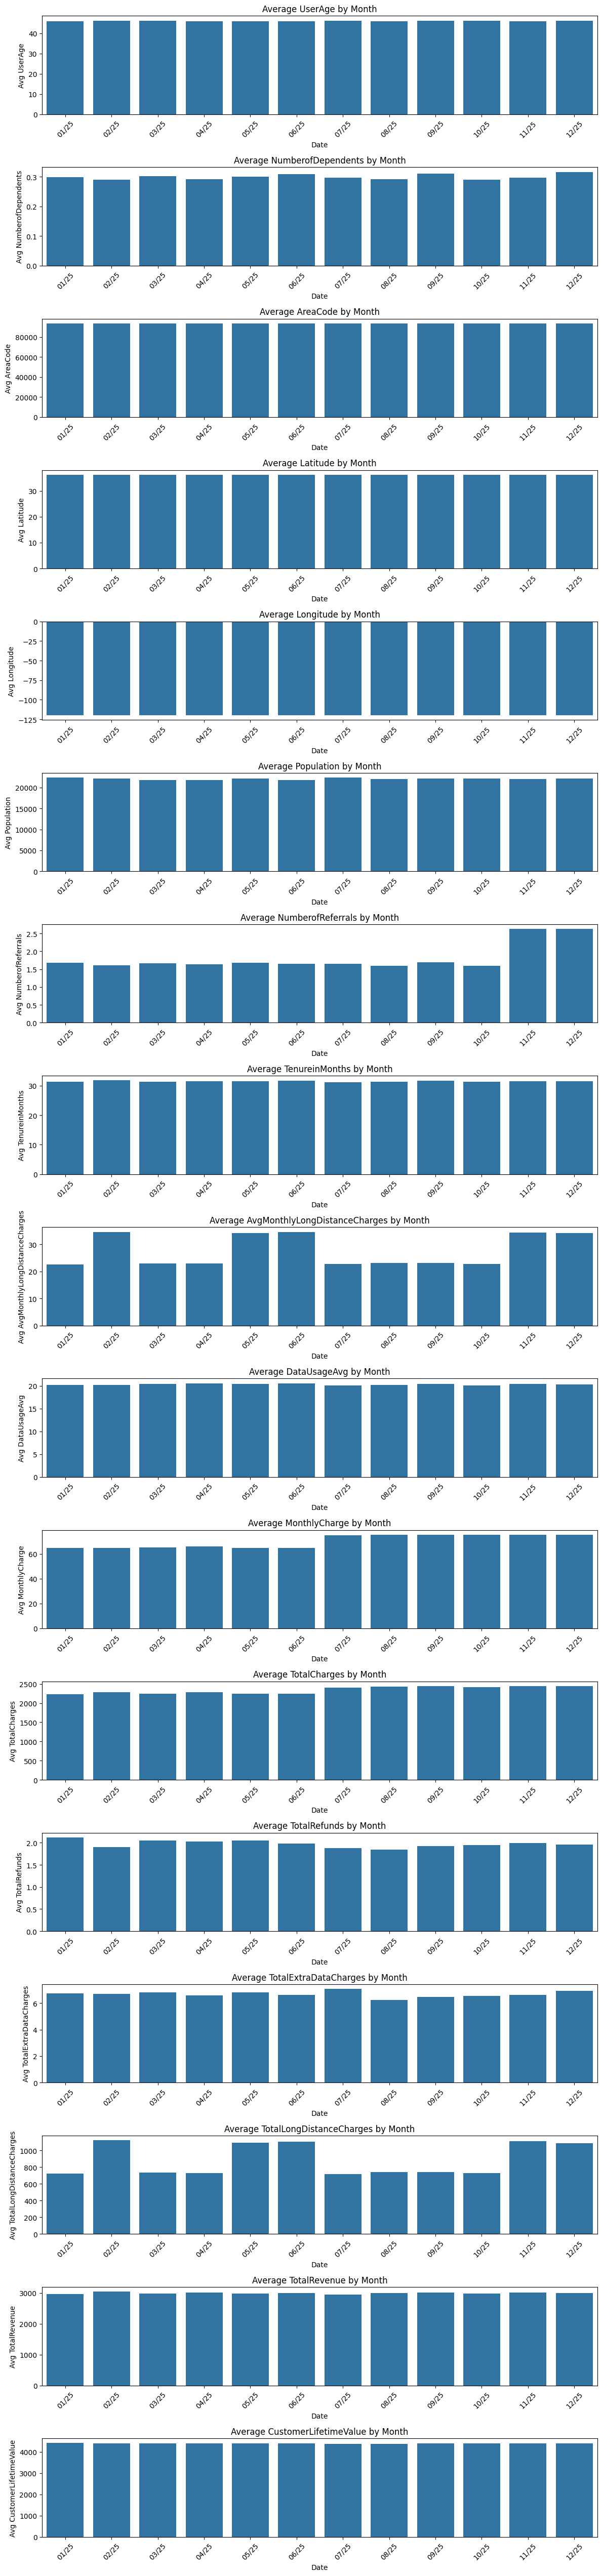

In [83]:
numerical_cols = df.select_dtypes(include='number').columns.tolist()
avg_num_values = df.groupby("Date")[numerical_cols].mean().reset_index()

fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(12, 3 * len(numerical_cols)))

for i, col in enumerate(numerical_cols):
    sns.barplot(data=avg_num_values, x="Date", y=col, ax=axes[i])
    axes[i].set_title(f"Average {col} by Month")
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel(f"Avg {col}")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Churn Analysis

In [ ]:
# Churn rate over time (train only)
churn_by_month = train.groupby("Month")["ChurnStatus"].apply(lambda x: (x == "Yes").mean()).reset_index()
churn_by_month.columns = ["Month", "ChurnRate"]
churn_by_month["Date"] = pd.to_datetime(churn_by_month["Month"], format="%y-%b").dt.strftime("%m/%y")
churn_by_month = churn_by_month.sort_values("Date")

plt.figure(figsize=(10, 4))
plt.plot(churn_by_month["Date"], churn_by_month["ChurnRate"], marker="o")
plt.axhline(churn_by_month["ChurnRate"].mean(), linestyle="--", color="red", label="Mean churn rate")
plt.title("Churn Rate Over Time")
plt.xlabel("Month")
plt.ylabel("Churn Rate")
plt.ylim(0, 0.5)
plt.legend()
plt.tight_layout()
plt.show()

print(churn_by_month[["Date", "ChurnRate"]].to_string(index=False))

In [ ]:
# Churn rate by Contract type and InternetType
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, ["Contract", "InternetType"]):
    churn_by_cat = train.groupby(col)["ChurnStatus"].apply(lambda x: (x == "Yes").mean()).reset_index()
    churn_by_cat.columns = [col, "ChurnRate"]
    churn_by_cat = churn_by_cat.sort_values("ChurnRate", ascending=False)
    ax.bar(churn_by_cat[col], churn_by_cat["ChurnRate"])
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate")
    ax.set_xlabel(col)
    for bar, val in zip(ax.patches, churn_by_cat["ChurnRate"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005, f"{val:.1%}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# Correlation heatmap of numeric features vs churn
num_df = train.copy()
num_df["Churned"] = (num_df["ChurnStatus"] == "Yes").astype(int)
numeric_cols = num_df.select_dtypes(include="number").columns.tolist()

corr = num_df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Numeric Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# Top features correlated with churn
print("Correlation with Churned:")
print(corr["Churned"].drop("Churned").sort_values(key=abs, ascending=False).to_string())

## Feature Drift Analysis
Track how key numeric feature distributions shift month-over-month — important for detecting data/concept drift.

In [ ]:
# Month-over-month std of key numeric features (drift signal)
drift_cols = ["MonthlyCharge", "TotalCharges", "TenureinMonths", "DataUsageAvg",
              "AvgMonthlyLongDistanceCharges", "CustomerLifetimeValue", "TotalRevenue"]

monthly_stats = df[df["split"] == "train"].groupby("Date")[drift_cols].agg(["mean", "std"]).reset_index()

fig, axes = plt.subplots(len(drift_cols), 1, figsize=(12, 3 * len(drift_cols)))
for i, col in enumerate(drift_cols):
    means = monthly_stats[col]["mean"]
    stds = monthly_stats[col]["std"]
    dates = monthly_stats["Date"]
    axes[i].plot(dates, means, marker="o", label="mean")
    axes[i].fill_between(dates, means - stds, means + stds, alpha=0.2, label="±1 std")
    axes[i].set_title(f"{col} — Mean ± Std by Month")
    axes[i].set_xlabel("Month")
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Churn rate breakdown by top categorical features
churn_features = ["Contract", "InternetType", "ConnectivityType", "TransactionMode", "UnlimitedData", "Offer"]

fig, axes = plt.subplots(len(churn_features), 1, figsize=(12, 4 * len(churn_features)))

for i, col in enumerate(churn_features):
    tmp = train.copy()
    tmp[col] = tmp[col].fillna("null")
    churn_rate = tmp.groupby(col)["ChurnStatus"].apply(lambda x: (x == "Yes").mean()).reset_index()
    churn_rate.columns = [col, "ChurnRate"]
    count = tmp[col].value_counts().reset_index()
    count.columns = [col, "Count"]
    merged = churn_rate.merge(count, on=col).sort_values("ChurnRate", ascending=False)

    bars = axes[i].bar(merged[col], merged["ChurnRate"])
    axes[i].set_title(f"Churn Rate by {col}")
    axes[i].set_ylabel("Churn Rate")
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis="x", rotation=30)
    for bar, (_, row) in zip(bars, merged.iterrows()):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                     f"{row['ChurnRate']:.1%}\n(n={row['Count']})", ha="center", fontsize=8)

plt.tight_layout()
plt.show()